# Installing Libraries

In [4]:
!which python

/home/ahmad/miniconda3/envs/langchain/bin/python


In [2]:
# %%bash
# pip -q install trl
# pip -q install peft
# pip -q install torch
# pip -q install datasets
# pip -q install transformers
# pip -q install tiktoken

In [3]:
# %%bash
# pip -q install pandas
# pip -q install numpy
# pip -q install matplotlib

## Import and view dataset

In [5]:
import torch
from trl import SFTTrainer
from datasets import load_dataset, load_from_disk
from peft import LoraConfig, get_peft_model, prepare_model_for_int8_training
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from pathlib import Path

### Test CUDA

In [6]:
device = torch.device("cuda")
torch.cuda.get_device_name(device)

'NVIDIA RTX A2000 Laptop GPU'

In [2]:
# import os

# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:256"

### Train Data

In [7]:
datasetPath = Path("/home/ahmad/llmDataset") / "tatsu-lab_alpaca"

if datasetPath.is_dir():
    train_dataset = load_from_disk(datasetPath)
else:
    train_dataset = load_dataset("tatsu-lab/alpaca")
    train_dataset.save_to_disk(datasetPath)

In [8]:
pandas_format = train_dataset.to_pandas()
display(pandas_format.head(3))

,instruction,input,output,text
0,Give three tips for staying healthy.,,1.Eat a balanced diet and make sure to include...,Below is an instruction that describes a task....
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....
2,Describe the structure of an atom.,,"An atom is made up of a nucleus, which contain...",Below is an instruction that describes a task....


# LLM

In [9]:
pretrained_model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
model = AutoModelForCausalLM.from_pretrained(pretrained_model_name, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name, trust_remote_code=True)

### Training Args

In [10]:
model_training_args = TrainingArguments(
       output_dir="TinyLlama-1.1B-Chat-v1.0-fine-tuned",
       per_device_train_batch_size=4,
       optim="adamw_torch",
       logging_steps=80,
       learning_rate=2e-4,
       warmup_ratio=0.1,
       lr_scheduler_type="linear",
       num_train_epochs=1,
       save_strategy="epoch"
   )

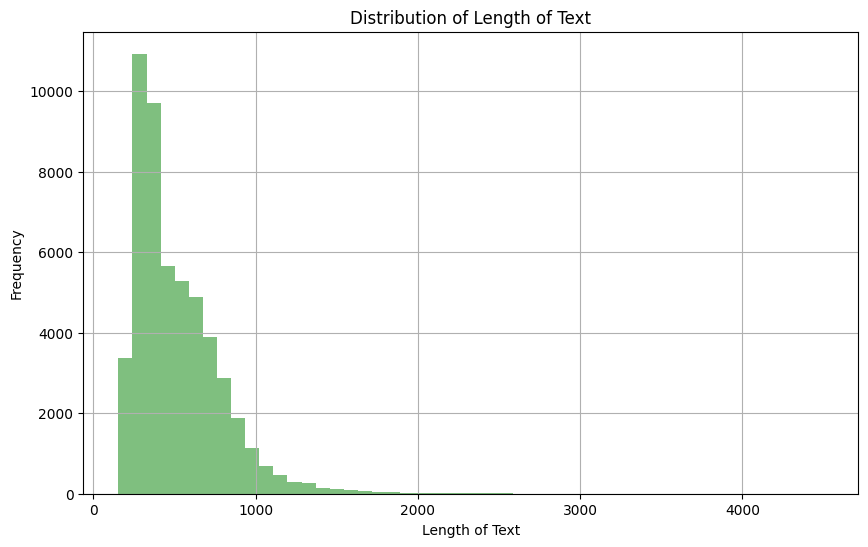

In [11]:
import matplotlib.pyplot as plt


pandas_format['text_length'] = pandas_format['text'].apply(len)


plt.figure(figsize=(10,6))
plt.hist(pandas_format['text_length'], bins=50, alpha=0.5, color='g')
plt.title('Distribution of Length of Text')
plt.xlabel('Length of Text')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [12]:
mask = pandas_format['text_length'] > 1024
percentage = (mask.sum() / pandas_format['text_length'].count()) * 100

print(f"The percentage of text documents with a length greater than 1024 is: {percentage}%")

The percentage of text documents with a length greater than 1024 is: 4.499826929733472%


### Trainer

In [18]:
# torch.cuda.empty_cache()

In [14]:
lora_peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

In [15]:
SFT_trainer = SFTTrainer(
       model=model,
       train_dataset=train_dataset,
       dataset_text_field="text",
       max_seq_length=1024,
       tokenizer=tokenizer,
       args=model_training_args,
       packing=True,
       peft_config=lora_peft_config,
   )

Generating train split: 0 examples [00:00, ? examples/s]

In [19]:
tokenizer.pad_token = tokenizer.eos_token
model.resize_token_embeddings(len(tokenizer))
model = prepare_model_for_int8_training(model)
model = get_peft_model(model, lora_peft_config)
training_args = model_training_args
trainer = SFT_trainer
trainer.train()

OutOfMemoryError: CUDA out of memory. Tried to allocate 44.00 MiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 3.32 GiB is allocated by PyTorch, and 141.68 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)